<a href="https://colab.research.google.com/github/deepto123/Neural-Networks-and-LLMs/blob/main/Ch-3%3A%20Making_a_context_aware_model_and_understanding_batch_normalisation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
names = open('/content/drive/MyDrive/Learning LLMs/names.txt', 'r').read().splitlines()

In [ ]:
chars = sorted(list(set(''.join(names))))
stoi = {ch:i+1 for i, ch in enumerate(chars)}
stoi['.'] = 0
print(stoi)

itos = {i:s for s,i in stoi.items()}
print(itos)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [ ]:
# build the dataset
context_window = 3

xs = []
ys = []
for name in names[:]:
  string = ['.'] *3 + list(name) + ['.']
  for i in range(len(string) - context_window):
    context = [stoi[ch] for ch in string[i:i+context_window]]
    output = stoi[string[i+context_window]]

    xs.append(context)
    ys.append(output)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
print(xs.shape)
print(ys)

torch.Size([228146, 3])
tensor([ 5, 13, 13,  ..., 26, 24,  0])


In [ ]:
xs.shape, xs.dtype, ys.shape, ys.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [ ]:
# Now we need to create the embedding model. Lets use a 2d space for 27 characters

C = torch.randn((27,2))
C

tensor([[-1.0042, -0.3065],
        [ 0.6958,  0.1613],
        [-0.3381,  0.0509],
        [-0.4663, -0.8536],
        [-1.1381, -0.9116],
        [-0.9092,  0.1205],
        [ 0.1146,  0.7323],
        [-0.1427,  2.2038],
        [-0.4962, -1.6163],
        [ 1.1645,  1.5875],
        [-1.0736,  0.1433],
        [-1.8867, -0.5325],
        [ 2.3997, -2.2031],
        [-2.8487,  0.7189],
        [-0.3927,  0.1242],
        [ 0.4057,  0.1645],
        [-0.6286, -0.7541],
        [-0.8369,  0.5295],
        [ 1.5943,  1.8627],
        [-0.8581,  1.1013],
        [-0.1932, -0.8808],
        [-0.4223, -0.6723],
        [-1.4508, -0.1168],
        [ 0.5423, -2.0511],
        [-0.0261, -0.6191],
        [-1.3152,  1.1895],
        [ 0.1644,  0.2712]])

In [ ]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

# in the previous lecture we used one hat encodings and then matrix multiplied by weights to get
# the logits. However we can clearly see that since others are 0, we get the value corresponding to C[5]
# So theres no nee for 1 hot encoding

tensor([-0.9092,  0.1205])

In [ ]:
C[5]

tensor([-0.9092,  0.1205])

In [ ]:
C[torch.tensor([5,6,7,7,7])]

tensor([[-0.9092,  0.1205],
        [ 0.1146,  0.7323],
        [-0.1427,  2.2038],
        [-0.1427,  2.2038],
        [-0.1427,  2.2038]])

In [ ]:
# we can also index with ,ulti dimensional tensor of integers
# xs can produce outputs ranging from 0 to 26. C acts as embedding vector, when something
# comes to C it will check in its lookup whether its present and return the value

C[xs]

tensor([[[-1.0042, -0.3065],
         [-1.0042, -0.3065],
         [-1.0042, -0.3065]],

        [[-1.0042, -0.3065],
         [-1.0042, -0.3065],
         [-0.9092,  0.1205]],

        [[-1.0042, -0.3065],
         [-0.9092,  0.1205],
         [-2.8487,  0.7189]],

        ...,

        [[ 0.1644,  0.2712],
         [ 0.1644,  0.2712],
         [-1.3152,  1.1895]],

        [[ 0.1644,  0.2712],
         [-1.3152,  1.1895],
         [ 0.1644,  0.2712]],

        [[-1.3152,  1.1895],
         [ 0.1644,  0.2712],
         [-0.0261, -0.6191]]])

In [ ]:
xs[13,2]

tensor(1)

In [ ]:
C[xs][13,2] == C[1]

tensor([True, True])

In [ ]:
emb = C[xs]
emb.shape

torch.Size([228146, 3, 2])

In [ ]:
# for the hidden layer , we want lets say 100 neurons. So our matrix will be [input, output]
# now we have 2d embeddings and we have 3 embeddings per input. So input will be x = 6
#  lets assume output =100 as we want 100 neurons in output

W1 = torch.randn((6, 100))
b = torch.randn(100)


https://blog.ezyang.com/2019/05/pytorch-internals/

In [ ]:
hidden_layer = torch.tanh(emb.view(-1, 6) @ W1 + b)
hidden_layer

tensor([[-0.9808, -0.9427,  0.9977,  ...,  0.8847, -0.9684, -0.1032],
        [-0.9852, -0.9681,  0.9968,  ...,  0.7419, -0.8950,  0.6215],
        [-0.4516, -0.5570,  1.0000,  ...,  0.9328, -0.9999,  0.9879],
        ...,
        [ 0.1229, -0.8230,  0.9990,  ...,  0.0489, -0.9522,  0.9948],
        [ 0.3360, -0.9994, -0.5078,  ...,  0.3640, -0.4109,  0.4821],
        [ 0.8420, -0.9666,  0.8779,  ..., -0.9978, -0.9718, -0.4612]])

In [ ]:
hidden_layer.shape

torch.Size([228146, 100])

In [ ]:
# broadcasting

# 32, 100
# 100

# 32, 100
# 1, 100

# hence broadcastable as addition will take rowwise

In [ ]:
# for the 2nd layer

# we will need to output any of the 27 charactrs so 27 outputs
# as input we will take the previous 100 neurons from last layer

W2 = torch.randn((100, 27))
b2 = torch.randn(27)

logits = hidden_layer @ W2 +  b2

In [ ]:
logits.shape

torch.Size([228146, 27])

In [ ]:
counts = logits.exp()
prob = counts/ counts.sum(dim=1, keepdim=True)
prob

tensor([[9.7173e-03, 1.4363e-06, 2.2985e-10,  ..., 7.7787e-09, 7.5462e-09,
         1.6375e-06],
        [1.4701e-04, 5.9668e-09, 6.7933e-11,  ..., 6.9835e-10, 3.7777e-08,
         9.9546e-09],
        [6.0730e-07, 1.1852e-09, 7.6491e-10,  ..., 2.5301e-12, 9.0581e-13,
         1.0348e-10],
        ...,
        [3.0335e-04, 3.1198e-06, 2.4383e-07,  ..., 7.1806e-09, 3.6290e-04,
         1.3909e-04],
        [1.4237e-07, 6.3644e-02, 4.3484e-09,  ..., 4.8935e-13, 6.8923e-06,
         1.1411e-05],
        [2.5449e-03, 7.6999e-05, 5.3568e-11,  ..., 2.0241e-07, 4.6951e-07,
         8.0442e-06]])

In [ ]:
prob[0].sum()

tensor(1.)

In [ ]:
prob[torch.arange(len(prob[:,0])), ys] ## returna the probability of the actual output

tensor([9.9633e-07, 1.7989e-05, 5.1054e-01,  ..., 1.3909e-04, 4.8935e-13,
        2.5449e-03])

In [ ]:
loss = -prob[torch.arange(len(xs)), ys].log().mean()
loss

tensor(14.8200)

In [ ]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

In [ ]:
sum(p.nelement() for p in parameters) ## total number of parameteers

3481

In [ ]:
emb = C[xs]
hidden = torch.tanh(emb.view(-1, 6) @ W1 + b1) # 32*100
logits = hidden @ W2 + b2 ## (32, 27)

# counts = logits.exp()
# prob = counts/ counts.sum(dim=1, keepdim=True)
# loss = -prob[torch.arange(len(xs)), ys].log().mean()

# The above 3 lines can be replaced by cross entropy function which doesnt create the intermediate tensors
# 1. It optimises time and space complexity - faster and memory efficient
# 2. Suppose the numbers logits are very high, lets say [-100, 3, 5, 100] For 100, e**100 gives infinity
#    To prevent this, cross entropy substracts max(tensor) and then caclulates the loss

loss = F.cross_entropy(logits, ys)
print(loss)

tensor(19.5052)


In [ ]:
for p in parameters:
  p.requires_grad = True

In [ ]:

for _ in range(10000):

  # minibatch construct
  ix = torch.randint(0, xs.shape[0], (32,)) # return 32 random numbers between 0 and given number

  # forward pass
  emb = C[xs[ix]] # get embedding of the batch returned
  hidden = torch.tanh(emb.view(-1, 6) @ W1 + b1) # 32*100
  logits = hidden @ W2 + b2 ## (32, 27)
  loss = F.cross_entropy(logits, ys[ix]) #compare the result with expected outputs
  # print(loss)

  # backward pass
  for p in parameters:
    p.grad =None
  loss.backward()

  # update the weights
  for p in parameters:
    p.data -= .01 * p.grad

In [ ]:
# Now if we see there are only 32 examples and 3k+ params, so this is a typical example of overfitting the data and
# the loss comes out to be very low

In [ ]:
logits.max(1)

torch.return_types.max(
values=tensor([2.2281, 1.5834, 3.0152, 1.8506, 3.7318, 2.5363, 1.6836, 2.6578, 1.1903,
        2.9140, 2.6578, 2.5820, 1.4755, 2.0406, 2.6350, 2.3663, 1.3535, 2.6578,
        1.1903, 3.9963, 1.2869, 3.9963, 2.0564, 1.4486, 3.1038, 2.7687, 3.1097,
        2.1005, 1.2869, 2.1909, 2.8942, 1.9043], grad_fn=<MaxBackward0>),
indices=tensor([ 1, 14,  0,  1,  1,  0,  1, 13, 18,  0, 13,  0,  0,  5,  0,  0, 18, 13,
        18,  1, 18,  1,  9, 14,  0,  0,  0,  0, 18,  5,  0,  0]))

In [ ]:
ys

tensor([ 5, 13, 13,  ..., 26, 24,  0])

# Mini batch

If our dataset scales, we can create mini batches for learning instead of doing forward and back propagation for 200k examples which is way slower.

Its much better to work with an approximate gradient and take more steps than to evaludate the exact gradient(by forward and back propagation) and take fewer steps

In [ ]:
# lets calculate loss for all of X vs Y

emb = C[xs]
hidden = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = hidden @ W2 + b2
loss = F.cross_entropy(logits, ys)
print(loss)

tensor(2.5709, grad_fn=<NllLossBackward0>)


# Learning rate

Currently .1 is our learning rate but how do we decide whats a good learning rate?

In [ ]:
# We create ann array of learning rates at equal spacing

learning_rate_exp = torch.linspace(-3, 0, 1000)
learning_rates = 10 ** learning_rate_exp
learning_rates

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [ ]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True

losses = []

for i in range(1000):

  # minibatch construct
  ix = torch.randint(0, xs.shape[0], (32,)) # return 32 random numbers between 0 and given number

  # forward pass
  emb = C[xs[ix]] # get embedding of the batch returned
  hidden = torch.tanh(emb.view(-1, 6) @ W1 + b1) # 32*100
  logits = hidden @ W2 + b2 ## (32, 27)
  loss = F.cross_entropy(logits, ys[ix]) #compare the result with expected outputs
  losses.append(loss.item())
  print(loss.item())

  # backward pass
  for p in parameters:
    p.grad =None
  loss.backward()

  # update the
  learning_rate = learning_rates[i]
  for p in parameters:
    p.data -= learning_rate * p.grad


19.85559844970703
17.656232833862305
18.189531326293945
16.968595504760742
18.740392684936523
18.438398361206055
18.804750442504883
19.414125442504883
19.416767120361328
17.488567352294922
20.878829956054688
19.277381896972656
18.43355941772461
16.228971481323242
17.536062240600586
18.641277313232422
16.42057228088379
18.88088035583496
18.21072769165039
18.753297805786133
22.458646774291992
18.741050720214844
20.839750289916992
15.461209297180176
20.169540405273438
17.444063186645508
21.433687210083008
19.095426559448242
19.56084442138672
17.76577377319336
20.024049758911133
18.99268913269043
17.473628997802734
17.350507736206055
19.96034049987793
17.5352840423584
15.198715209960938
18.833709716796875
17.959064483642578
16.470230102539062
17.5028076171875
17.29525375366211
15.722594261169434
18.92534637451172
18.59593391418457
17.373659133911133
18.55171775817871
16.4765625
16.252399444580078
18.67142105102539
19.728103637695312
16.45336151123047
15.77109432220459
18.702600479125977
18

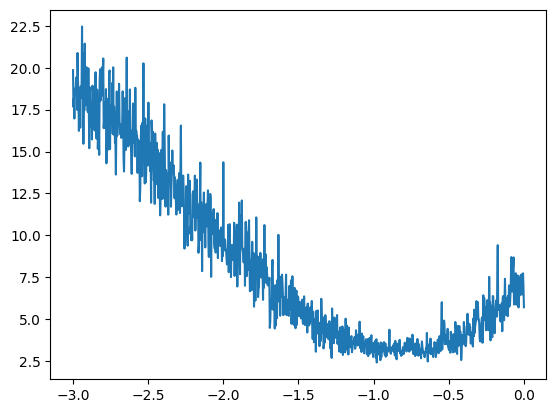

In [ ]:
plt.plot(learning_rate_exp, losses)

In [ ]:
# by plotting we ca easily find the learning rate where losses are low

# So sometimes we will train our model with the optimal learnng rate say 0.1 till
# the losses become stagnant and then do learing rate decay to further reduce the loss

Now if the number of parameters/ capacity of the neural networks keep on increasing, the model will be overfitting i.e. less number of training data and more params and basically the model will memeorise the training set at the point. So it will always generate results as to what it has already seen in the training set.

So the idea is to separate the dataset into 3 parts
1. Train - Tune the parameters like embeddings, weights
2. Dev/Validation - Tune the hyperparameters like embedding size/ number of neurons in hidden layer etc
3. Test- Only for testing

In [ ]:
# training split, val split, test split
# 80%, 10%, 10%

In [ ]:
# build the dataset
context_window = 3

def build_dataset(words):

  xs = []
  ys = []
  for name in words:
    string = ['.'] *3 + list(name) + ['.']
    for i in range(len(string) - context_window):
      context = [stoi[ch] for ch in string[i:i+context_window]]
      output = stoi[string[i+context_window]]

      xs.append(context)
      ys.append(output)

  xs = torch.tensor(xs)
  ys = torch.tensor(ys)
  return xs, ys

import random
random.seed(42)
random.shuffle(names)

n1 = int(0.8 * len(names))
n2 = int(0.9 * len(names))

print(n1)
print(n2)
x_train, y_train = build_dataset(names[:n1])
x_val, y_val = build_dataset(names[n1:n2])
x_test, y_test = build_dataset(names[n2:])

print(len(x_train))
print(len(x_val))
print(len(x_test))

25626
28829
182625
22655
22866


In [ ]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True

In [ ]:
losses = []
steps = []
i=0

In [ ]:
for _ in range(50000):

  # minibatch construct
  ix = torch.randint(0, x_train.shape[0], (32,)) # return 32 random numbers between 0 and given number

  # forward pass
  emb = C[x_train[ix]] # get embedding of the batch returned
  hidden = torch.tanh(emb.view(-1, 6) @ W1 + b1) # 32*100
  logits = hidden @ W2 + b2 ## (32, 27)
  loss = F.cross_entropy(logits, y_train[ix]) #compare the result with expected outputs
  # print(loss)

  # backward pass
  for p in parameters:
    p.grad =None
  loss.backward()

  # update the weights
  for p in parameters:
    p.data -= .01 * p.grad

  # track matrics
  i+=1
  losses.append(loss.item())
  steps.append(i)

print(loss)

tensor(2.3219, grad_fn=<NllLossBackward0>)


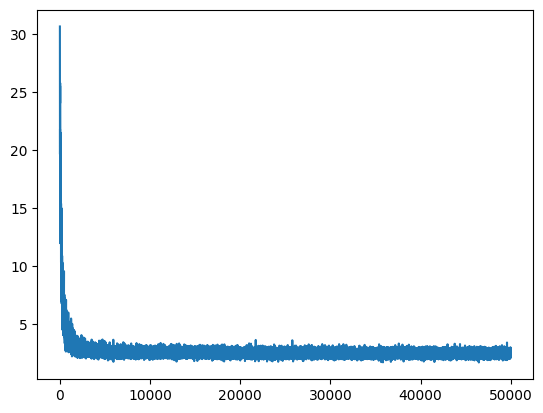

In [ ]:
plt.plot(steps, losses)

In [ ]:
# lets now test our model on train set

emb = C[x_train]
hidden = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = hidden @ W2 + b2
loss = F.cross_entropy(logits, y_train)
print(loss)

tensor(2.4427, grad_fn=<NllLossBackward0>)


In [ ]:
# lets now test our model on dev set

emb = C[x_val]
hidden = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = hidden @ W2 + b2
loss = F.cross_entropy(logits, y_val)
print(loss)

tensor(2.4332, grad_fn=<NllLossBackward0>)


In [ ]:
# lets now test our model on test set

emb = C[x_test]
hidden = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = hidden @ W2 + b2
loss = F.cross_entropy(logits, y_test)
print(loss)

tensor(2.4384, grad_fn=<NllLossBackward0>)


In [ ]:
# We see that after first iteration train, dev and test losses are equal. That also means that
# the model hasnt memeorised the whole dataset yet and by no means we are overfitting.
# Instead we can conclude we are underffitting

## Performance upgrade??

1. Adjust the learning rate - learning rate decay
2. Adjust the batch size
3. Regularisation factor
4. Adjust neurons in hidden layer
5. Adjust number of embeddings

A combination of all the optimal solutions will give the best performance/ lowest loss

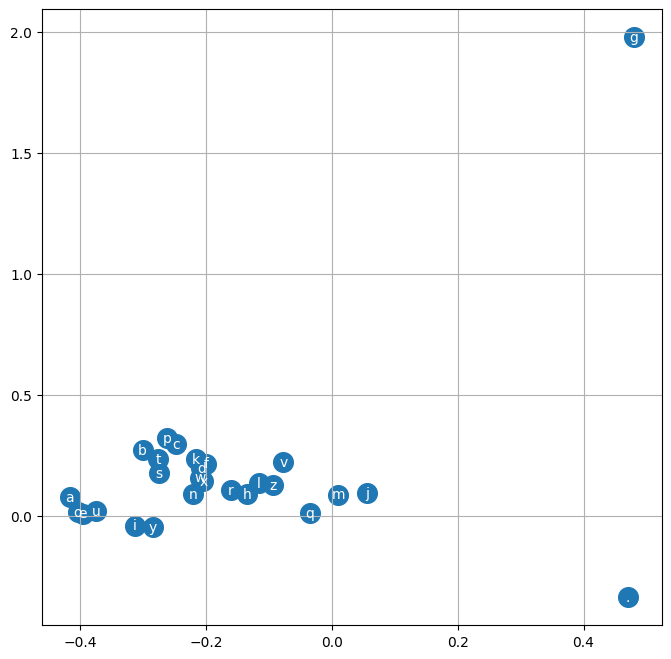

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [ ]:
# from visulaising the embedding we can see that vowels are all kept together, q and g is not used commonly so placed far away

In [ ]:
# lets increase the embedding size to 20 instead of 2

In [ ]:
embeddings = 10
hidden_layer_size = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, embeddings), generator=g)
W1 = torch.randn((context_window * embeddings, hidden_layer_size), generator=g)
b1 = torch.randn(hidden_layer_size, generator=g)
W2 = torch.randn((hidden_layer_size, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True

sum(p.nelement() for p in parameters)

11897

In [ ]:
losses = []
steps = []
i=0

In [ ]:
for _ in range(50000):

  # minibatch construct
  ix = torch.randint(0, x_train.shape[0], (100,)) # return 32 random numbers between 0 and given number

  # forward pass
  emb = C[x_train[ix]] # get embedding of the batch returned
  hidden = torch.tanh(emb.view(-1, context_window * embeddings) @ W1 + b1) # 32*100
  logits = hidden @ W2 + b2 ## (32, 27)
  loss = F.cross_entropy(logits, y_train[ix]) #compare the result with expected outputs
  # print(loss)

  # backward pass
  for p in parameters:
    p.grad =None
  loss.backward()

  # update the weights
  for p in parameters:
    p.data -= .005 * p.grad

  # track matrics
  i+=1
  losses.append(loss.item())
  steps.append(i)

print(loss)

tensor(2.1728, grad_fn=<NllLossBackward0>)


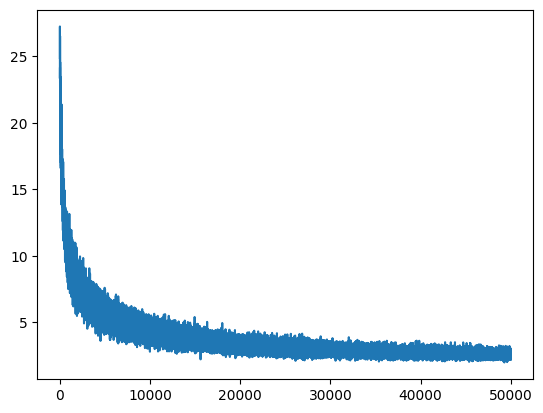

In [ ]:
plt.plot(steps, losses)

In [ ]:
# lets now test our model on train set

emb = C[x_train]
hidden = torch.tanh(emb.view(-1, context_window * embeddings) @ W1 + b1)
logits = hidden @ W2 + b2
loss = F.cross_entropy(logits, y_train)
print(loss)

tensor(2.5658, grad_fn=<NllLossBackward0>)


In [ ]:
# lets now test our model on dev set

emb = C[x_val]
hidden = torch.tanh(emb.view(-1, context_window * embeddings) @ W1 + b1)
logits = hidden @ W2 + b2
loss = F.cross_entropy(logits, y_val)
print(loss)

tensor(2.5704, grad_fn=<NllLossBackward0>)


In [ ]:
# lets now test our model on test set

emb = C[x_test]
hidden = torch.tanh(emb.view(-1, context_window * embeddings) @ W1 + b1)
logits = hidden @ W2 + b2
loss = F.cross_entropy(logits, y_test)
print(loss)

tensor(2.5969, grad_fn=<NllLossBackward0>)


In [ ]:
# now lets sample

g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
  result = ""
  context = [0] * context_window
  while True:
    # calculate the wx + b for given context
    emb = C[torch.tensor(context)]
    hidden = torch.tanh(emb.view(1, -1) @ W1 + b1)
    logits = hidden @ W2 + b2

    # do a softmax to get the prob
    probs = F.softmax(logits, dim =1)

    # sample to generate a character
    ix = torch.multinomial(probs, num_samples=1, generator=g).item()

    # shift the comtext window by 1
    context = context[1:] + [ix]

    #add the character to the result
    ch = itos[ix]
    result += ch

    # if end of word terminate
    if(ch == "."):
      break;

  print(result)

carlah.
amorilei.
kimyli.
thty.
salassie.
mahuen.
deliy.
calleei.
nerenistchaiir.
kaleig.
dham.
joce.
quinn.
srojdki.
jamii.
wazelo.
dearyxi.
jacen.
dusabee.
deco.


# Fixing the training loss


In [ ]:
# build the dataset
context_window = 3

def build_dataset(words):

  xs = []
  ys = []
  for name in words:
    string = ['.'] *3 + list(name) + ['.']
    for i in range(len(string) - context_window):
      context = [stoi[ch] for ch in string[i:i+context_window]]
      output = stoi[string[i+context_window]]

      xs.append(context)
      ys.append(output)

  xs = torch.tensor(xs)
  ys = torch.tensor(ys)
  return xs, ys

import random
random.seed(42)
random.shuffle(names)

n1 = int(0.8 * len(names))
n2 = int(0.9 * len(names))

print(n1)
print(n2)
x_train, y_train = build_dataset(names[:n1])
x_val, y_val = build_dataset(names[n1:n2])
x_test, y_test = build_dataset(names[n2:])

print(len(x_train))
print(len(x_val))
print(len(x_test))

25626
28829
182580
22767
22799


In [ ]:
embeddings = 10
hidden_layer_size = 200
vocab_size = 27

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embeddings), generator=g)
W1 = torch.randn((context_window * embeddings, hidden_layer_size), generator=g)
b1 = torch.randn(hidden_layer_size, generator=g)
W2 = torch.randn((hidden_layer_size, vocab_size), generator=g) * 0.01   # scaling he weights down to reduce initial loss
# we see that scaling the weights down to .01 reduces the loss close to 3.30, the ideal loss is 3.29 i.e. -log(1/27) when
# we assign equal probabilites to all the characters. But there is a reason we cant assign the weights intially.
b2 = torch.randn(vocab_size, generator=g) * 0   # we dont want to add a random bias

parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True

sum(p.nelement() for p in parameters)

11897

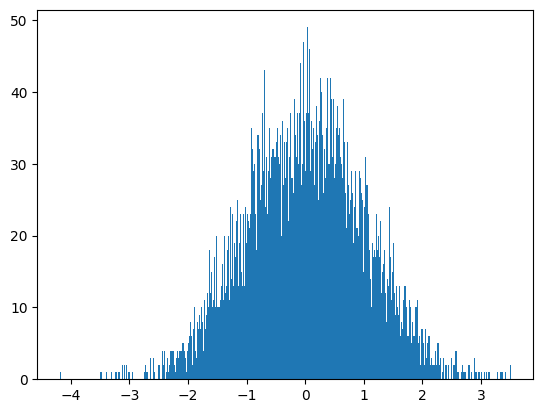

In [ ]:
# since we have intialised all weights and biases with torch.random we always get a gaussian distribution

plt.hist(W1.view(-1).tolist(), 500);

# but if we look closely at the gaussian distribution we see that the weights are heavily inclined to

In [ ]:
max_steps = 200000
batch_size = 32
losses = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, x_train.shape[0], (batch_size,)) # return 32 random numbers between 0 and given number
  x_batch = x_train[ix]
  y_batch = y_train[ix]

  # forward pass
  emb = C[x_batch] # get embedding of the batch returned
  embedding_concat = emb.view(-1, context_window * embeddings) # concatenate the vectors
  hidden_layer_preactivation = embedding_concat @ W1 + b1
  hidden = torch.tanh(hidden_layer_preactivation)
  logits = hidden @ W2 + b2
  loss = F.cross_entropy(logits, y_batch) #compare the result with expected outputs
  # print(loss)

  # backward pass
  for p in parameters:
    p.grad =None
  loss.backward()

  # update the weights
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data -= lr * p.grad

  # track matrics
  if i% 10000 == 0: #print every once in a while
    print(f'step:{i}, loss: {loss.item():.4f}')
  losses.append(loss.log10().item())  # this is done to faltten the loss in the graph
  break;
print(loss)

step:0, loss: 3.3356
tensor(3.3356, grad_fn=<NllLossBackward0>)


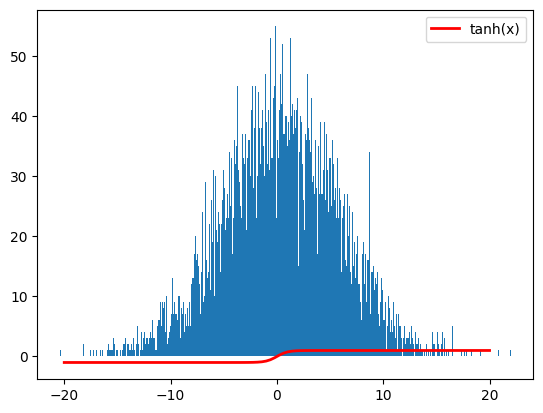

In [ ]:
import numpy as np

# 1. Plot your original histogram
plt.hist(hidden_layer_preactivation.view(-1).tolist(), 500)

# 2. Generate x values spanning the active region of tanh
x = torch.linspace(-20, 20, 100)
y = torch.tanh(x)

# 3. Scale y so it matches the height of your histogram (e.g., matching the peak around 60)
# Multiply by 60 so the curve stretches up to the top of your main distribution peak
plt.plot(x.numpy(), y.numpy(), color='red', linewidth=2, label='tanh(x)')

# 4. Show a legend to make it clean
plt.legend()
plt.show()

# after matrix multiplicaion, the preactivation is scattered from -10 to +10, so naturaaly the density of numbers is much more in the +1 and -1 region of tanh
# We call this saturated tanh

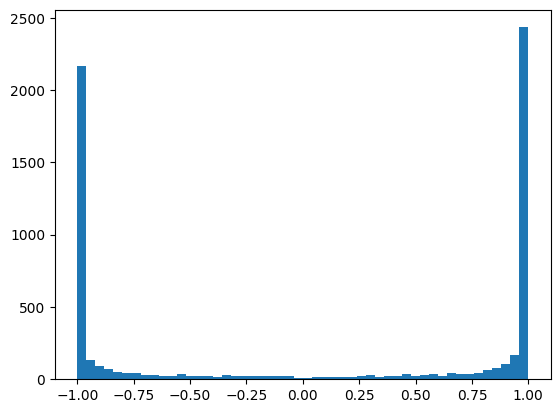

In [ ]:
# But why is it a nightmare - because basically if all our hidden layer neurons are in this range, the gradient will always be 0,
# have basically managed to kill the graident and the weights cant be changed now because p.data -= lr * p.grad we have p.grad =0.
plt.hist(hidden.view(-1).tolist(), 50);

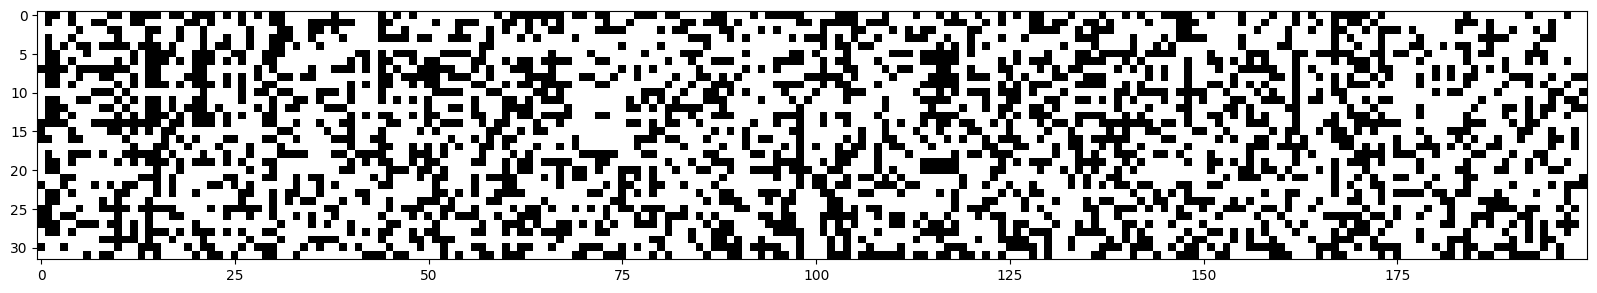

In [ ]:
plt.figure(figsize = (20, 10))
plt.imshow(hidden.abs() > 0.99, cmap = 'gray', interpolation = 'nearest')

# now lets plot and see where our neurons have values >0.99 (all the light areas)
# And we should have been deeply worried if had awhite line because that would basically mean a dead neuron
# that never activates

# but this isnt over as we can clearly see that the neurons are acyivated very less and there is not much learning going on
# lets increase the learning

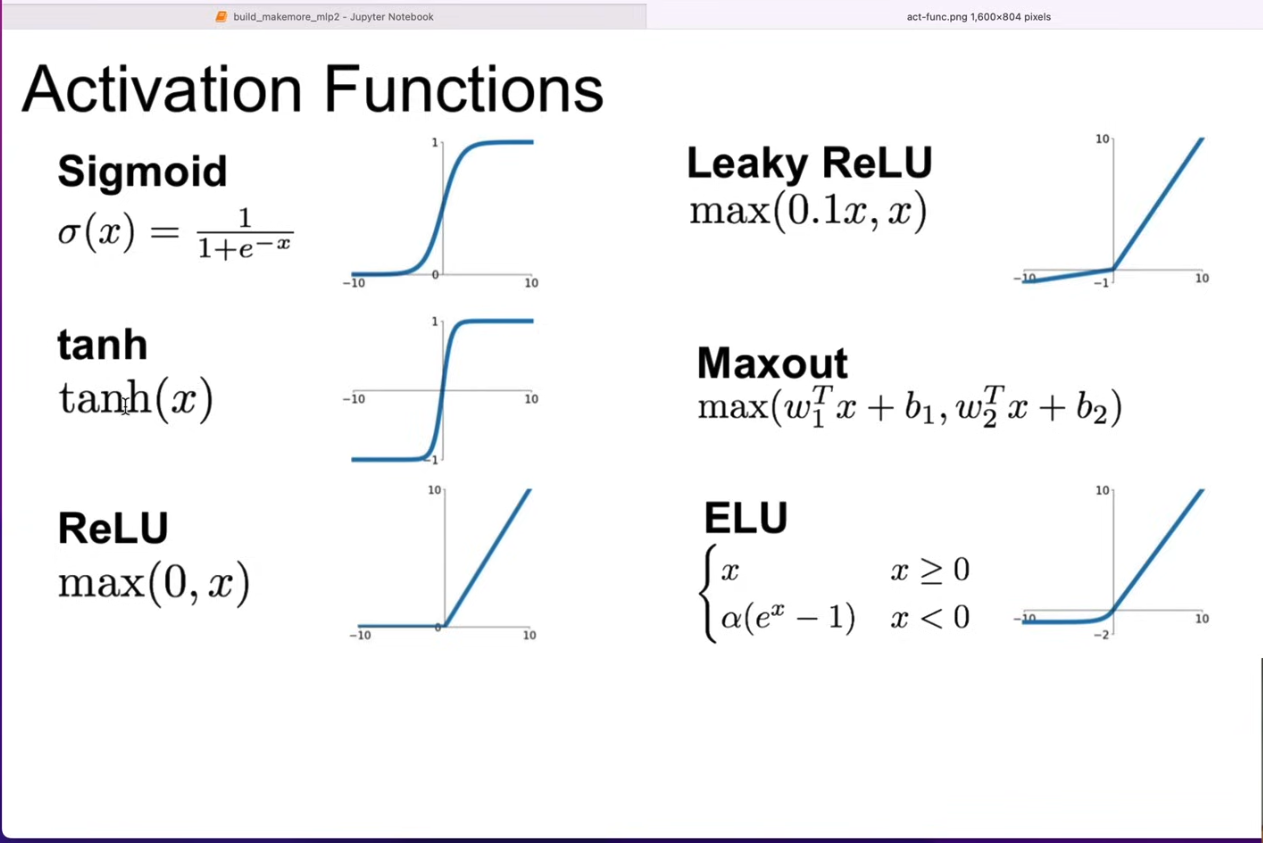

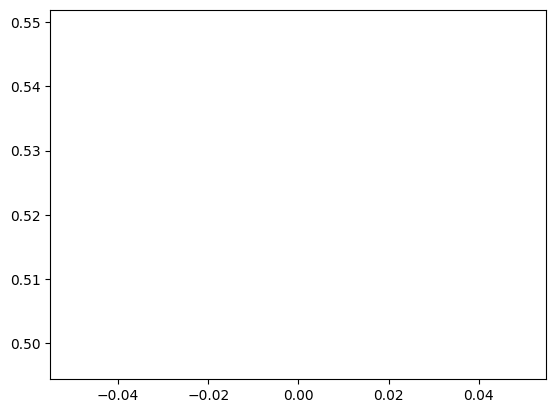

In [ ]:
# Now we see that we have removed the hockey shape appearance becaause by scaling doen the weights and removing the
# unnecessary biases we have removed the easy learning part and now we are only doin the hard learning

plt.plot(losses)

In [ ]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x, y = {
      'train': {x_train, y_train},
      'val': {x_val, y_val},
      'test': {x_test, y_test}
  }[split]

  emb = C[x] # get embedding of the batch returned
  embedding_concat = emb.view(-1, context_window * embeddings) # concatenate the vectors
  hidden_layer_preactivation = embedding_concat @ W1 + b1
  hidden = torch.tanh(hidden_layer_preactivation)
  logits = hidden @ W2 + b2
  loss = F.cross_entropy(logits, y) #compare the result with expected outputs
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 3.2309296131134033
val 3.2302839756011963


In [ ]:
# One very first thing we can notice at the start is that we start with a very high loss
# Now if we multiply the logits by a factor of 10, we see that the loss explodes. This is because the
# weights are being set far apart right now

# So in our use case also we we will also trying reducing the standar deviation of th weights so that
# we can reduce the intial loss

logits_example = torch.tensor([-4.0, 4.0, 2.0, -1.0]) * 10
probs_example = torch.softmax(logits, dim = 0)

loss_mean_example = -probs.log().mean()
print(loss_mean_example)

print(-torch.log(torch.tensor(1/27.0)))

tensor(10.3216, grad_fn=<NegBackward0>)
tensor(3.2958)


Lets rerun our model again

In [ ]:
embeddings = 10
hidden_layer_size = 200
vocab_size = 27

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embeddings), generator=g)
W1 = torch.randn((context_window * embeddings, hidden_layer_size), generator=g) * (5/3) / ((context_window * embeddings)**(0.5)) # * 0.2
b1 = torch.randn(hidden_layer_size, generator=g) * .01
W2 = torch.randn((hidden_layer_size, vocab_size), generator=g) * 0.01   # scaling he weights down to reduce initial loss
# we see that scaling the weights down to .01 reduces the loss close to 3.30, the ideal loss is 3.29 i.e. -log(1/27) when
# we assign equal probabilites to all the characters. But there is a reason we cant assign the weights intially.
b2 = torch.randn(vocab_size, generator=g) * 0   # we dont want to add a random bias


batch_norm_gain = torch.ones((1, hidden_layer_size))
batch_norm_bias = torch.zeros((1, hidden_layer_size))
print(batch_norm_gain.shape)

parameters = [C, W1, b1, W2, b2, batch_norm_gain, batch_norm_bias]

for p in parameters:
  p.requires_grad = True

sum(p.nelement() for p in parameters)

torch.Size([1, 200])


12297

In [ ]:
max_steps = 200000
batch_size = 32
losses = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, x_train.shape[0], (batch_size,)) # return 32 random numbers between 0 and given number
  x_batch = x_train[ix]
  y_batch = y_train[ix]

  # forward pass
  emb = C[x_batch] # get embedding of the batch returned
  embedding_concat = emb.view(-1, context_window * embeddings) # concatenate the vectors
  hidden_layer_preactivation = embedding_concat @ W1 + b1

  # batch normalisation
  # substract the mean and divide by standard deviation
  hidden_layer_preactivation = (hidden_layer_preactivation - hidden_layer_preactivation.mean(0, keepdim = True))/ hidden_layer_preactivation.std(0, keepdim = True)
  # scale and shift
  hidden_layer_preactivation = batch_norm_gain * hidden_layer_preactivation + batch_norm_bias

  hidden = torch.tanh(hidden_layer_preactivation)
  logits = hidden @ W2 + b2
  loss = F.cross_entropy(logits, y_batch) #compare the result with expected outputs
  # print(loss)

  # backward pass
  for p in parameters:
    p.grad =None
  loss.backward()

  # update the weights
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data -= lr * p.grad

  # track metrics
  if i% 10000 == 0: #print every once in a while
    print(f'step:{i}, loss: {loss.item():.4f}')
  losses.append(loss.log10().item())  # this is done to faltten the loss in the graph

print(loss.item())

step:0, loss: 3.3032
step:10000, loss: 2.3741
step:20000, loss: 2.2288
step:30000, loss: 2.0503
step:40000, loss: 2.4384
step:50000, loss: 2.1606
step:60000, loss: 2.1019
step:70000, loss: 2.5066
step:80000, loss: 2.2545
step:90000, loss: 2.3324
step:100000, loss: 2.2980
step:110000, loss: 1.9971
step:120000, loss: 1.8295
step:130000, loss: 2.5210
step:140000, loss: 2.3535
step:150000, loss: 1.9064
step:160000, loss: 1.7217
step:170000, loss: 1.6678
step:180000, loss: 1.9891
step:190000, loss: 1.8231
1.9135233163833618


In [ ]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x, y = {
      'train': {x_train, y_train},
      'val': {x_val, y_val},
      'test': {x_test, y_test}
  }[split]

  emb = C[x] # get embedding of the batch returned
  embedding_concat = emb.view(-1, context_window * embeddings) # concatenate the vectors
  hidden_layer_preactivation = embedding_concat @ W1 + b1

  # batch normalisation
  # substract the mean and divide by standard deviation
  hidden_layer_preactivation = (hidden_layer_preactivation - hidden_layer_preactivation.mean(0, keepdim = True))/ hidden_layer_preactivation.std(0, keepdim = True)
  # scale and shift
  hidden_layer_preactivation = batch_norm_gain * hidden_layer_preactivation + batch_norm_bias

  hidden = torch.tanh(hidden_layer_preactivation)
  logits = hidden @ W2 + b2
  loss = F.cross_entropy(logits, y) #compare the result with expected outputs
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.064689874649048
val 2.111419677734375


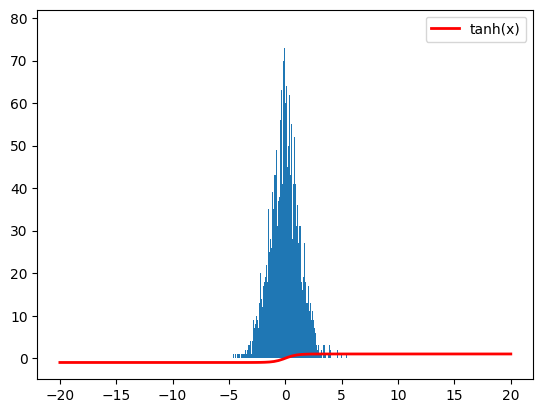

In [ ]:
import numpy as np

# 1. Plot your original histogram
plt.hist(hidden_layer_preactivation.view(-1).tolist(), 500)

# 2. Generate x values spanning the active region of tanh
x = torch.linspace(-20, 20, 100)
y = torch.tanh(x)

# 3. Scale y so it matches the height of your histogram (e.g., matching the peak around 60)
# Multiply by 60 so the curve stretches up to the top of your main distribution peak
plt.plot(x.numpy(), y.numpy(), color='red', linewidth=2, label='tanh(x)')

# 4. Show a legend to make it clean
plt.legend()
plt.show()

# after matrix multiplicaion, the preactivation is scattered from -10 to +10, so naturaaly the density of numbers is much more in the +1 and -1 region of tanh
# We call this saturated tanh

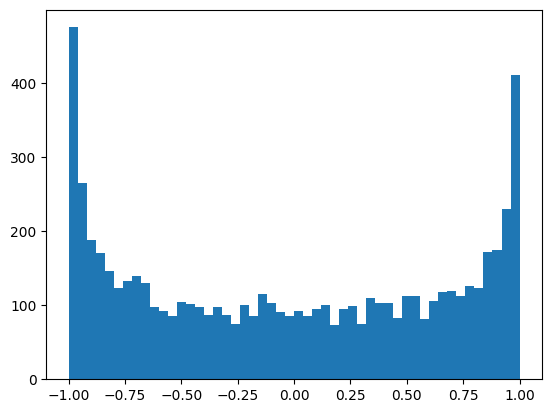

In [ ]:
# But why is it a nightmare - because basically if all our hidden layer neurons are in this range, the gradient will always be 0,
# have basically managed to kill the graident and the weights cant be changed now because p.data -= lr * p.grad we have p.grad =0.
plt.hist(hidden.view(-1).tolist(), 50);

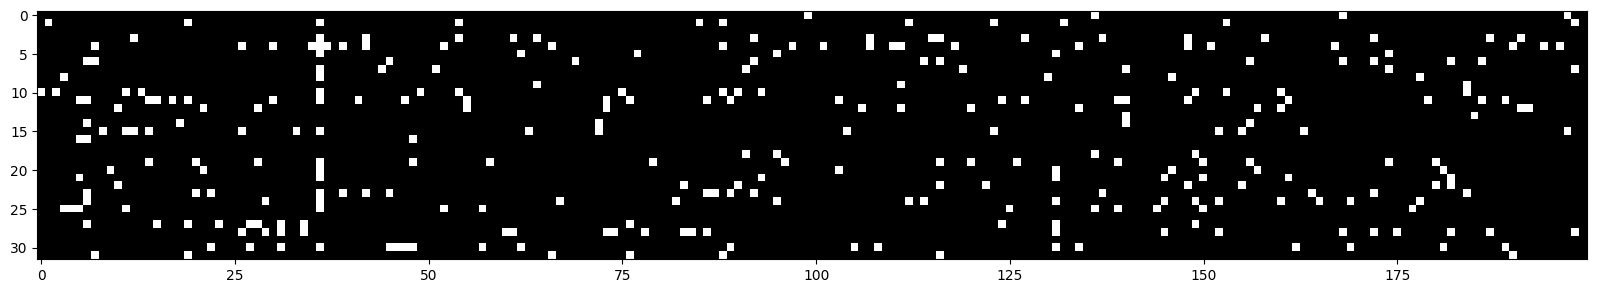

In [ ]:
plt.figure(figsize = (20, 10))
plt.imshow(hidden.abs() > 0.99, cmap = 'gray', interpolation = 'nearest')

# now lets plot and see where our neurons have values >0.99 (all the light areas)
# And we should have been deeply worried if had awhite line because that would basically mean a dead neuron
# that never activates

# but this isnt over as we can clearly see that the neurons are acyivated very less and there is not much learning going on
# lets increase the learning

tensor(0.0045) tensor(0.9882)
tensor(9.7929e-05) tensor(0.9608)


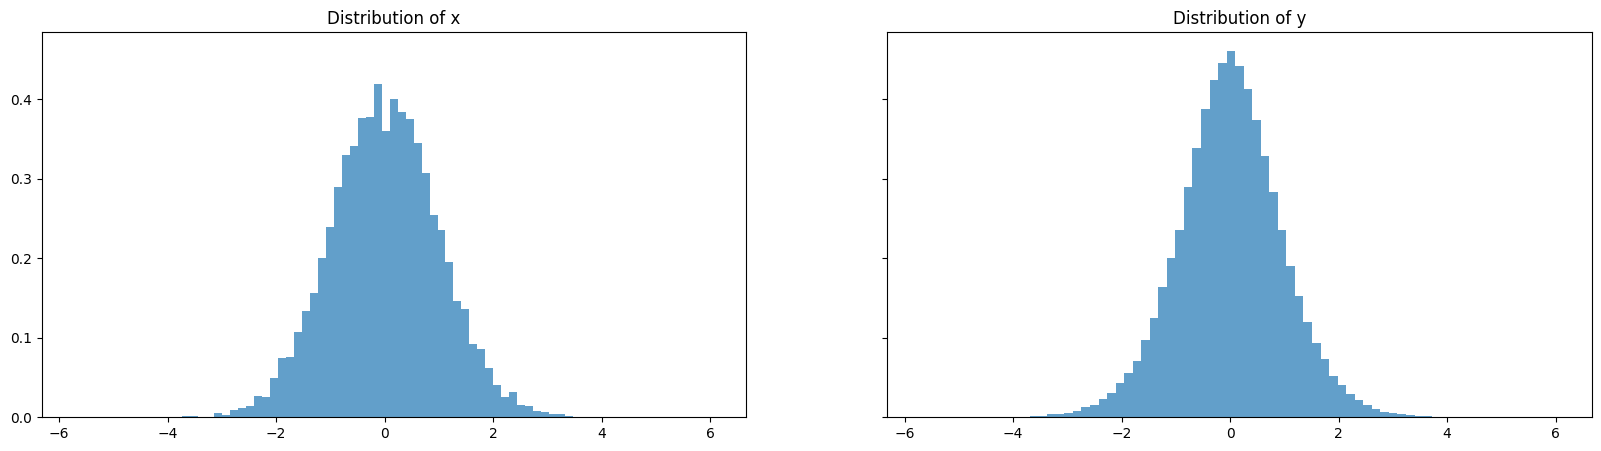

In [ ]:
import matplotlib.pyplot as plt
import torch

x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10 **0.5
y = x @ w

print(x.mean(), x.std())
print(y.mean(), y.std())

# Create a figure with 1 row and 2 columns, sharing both x and y axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5), sharex=True, sharey=True)

# Plot x in the first subplot
ax1.hist(x.view(-1).tolist(), 50, density=True, alpha=0.7)
ax1.set_title("Distribution of x")

# Plot y in the second subplot
ax2.hist(y.view(-1).tolist(), 75, density=True, alpha=0.7)
ax2.set_title("Distribution of y")

plt.show()

# We see how y is being flattened out gaussian. We want the gaussian to remain same and thats why
# we divide by sqaure root of fan_in (this comes from the veriance equation)

https://docs.pytorch.org/docs/2.12/nn.init.html#

Now modern innovations actually are stable and well behaved so we dont have to manually do these intialisation of weights exactly right and everything else.
1. Residual corrections
2. Normalisations
3. Better optmisers


In [ ]:
print(hidden_layer_preactivation.shape)

torch.Size([32, 200])


In [ ]:
hidden_layer_preactivation.mean(0, keepdim=True)
# we want the mean of all the examples in the batch for all the neurons

tensor([[ 2.0749e-01, -6.0709e-01,  9.8401e-02, -4.9326e-01, -1.5891e-01,
         -2.4067e-01,  1.1414e-03, -4.8676e-01,  4.8955e-01,  7.7906e-02,
          4.8568e-01,  5.8117e-01,  1.3468e-01, -6.4342e-02, -3.5989e-01,
         -9.9107e-02,  8.6744e-02,  7.8571e-02, -3.2279e-01,  4.7213e-01,
          6.9411e-04, -3.5443e-02, -4.5302e-01, -1.4891e-01, -2.3137e-02,
          4.7096e-02,  8.9407e-02, -3.4430e-01, -3.0305e-01,  1.3086e-01,
          1.6299e-02,  1.3432e-03, -2.1699e-01, -5.4426e-02,  2.1898e-01,
         -2.6057e-01,  1.5013e+00,  2.4168e-01, -5.2494e-01, -2.5325e-01,
          2.8218e-02,  1.2226e-01, -9.5775e-02, -1.5497e-01,  2.7894e-02,
          2.3055e-01, -3.9030e-01,  3.4160e-01, -3.1892e-01, -2.7295e-01,
         -7.3068e-02, -3.8272e-01, -4.9688e-01, -8.8140e-02, -8.1769e-01,
          2.2613e-01, -1.8397e-01,  1.0264e-01, -1.3174e-01, -3.9439e-02,
          1.2982e-01, -4.9857e-02,  1.5446e-01, -1.4017e-01,  1.4747e-01,
          2.4862e-01, -2.0074e-01, -1.

In [ ]:
hidden_layer_preactivation.std(0, keepdim=True)

tensor([[1.3300, 1.1065, 1.1687, 1.1916, 1.1632, 1.5540, 2.1190, 1.0539, 1.2558,
         1.1986, 1.2628, 1.4343, 1.5777, 1.1171, 1.4329, 1.5650, 1.0411, 1.2196,
         1.3455, 1.7704, 1.3340, 1.1890, 1.4180, 1.3762, 0.9429, 1.0132, 1.4865,
         1.4180, 1.4339, 1.3651, 1.2680, 1.7363, 1.2033, 1.2221, 1.2288, 1.0430,
         3.0938, 1.1061, 0.9311, 1.1501, 1.0922, 1.0959, 1.4914, 1.0530, 1.2951,
         1.6244, 1.1818, 1.3787, 1.7489, 1.2619, 1.2104, 1.3075, 1.1272, 0.8969,
         1.5318, 1.3431, 1.1088, 1.2807, 1.1853, 1.1491, 1.2279, 1.4033, 1.1581,
         1.1661, 1.3160, 0.9985, 1.1385, 1.2964, 1.2384, 1.0082, 1.2167, 1.2175,
         1.5011, 1.2850, 1.3387, 0.9523, 1.4529, 1.3755, 1.1431, 1.2112, 1.1582,
         0.7877, 1.2093, 1.3343, 1.1555, 1.1713, 1.5729, 1.3034, 1.4280, 1.5329,
         1.3677, 1.3280, 1.4257, 1.2626, 0.8134, 1.5370, 1.3030, 0.9715, 1.1507,
         1.1629, 1.4896, 1.1252, 0.9857, 1.4033, 0.9880, 1.4303, 1.3004, 1.4397,
         0.9839, 1.0602, 1.2

# Batch normalisation

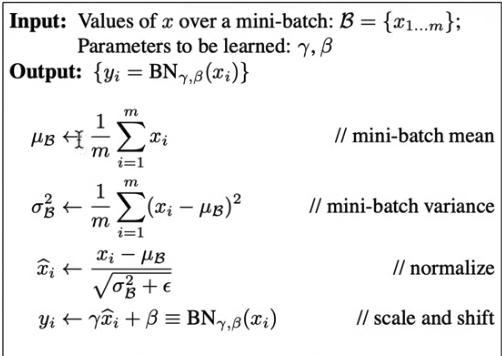


To normalize we substract from the mean(to center the data more towards 0) and divide by standard deviation to asjust the stretch

The epsilon is required in case standard deviation is 0

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 1. Setup the figure and plot the static background histogram
fig, ax = plt.subplots()
ax.hist(hidden_layer_preactivation.view(-1).tolist(), 500)

# 2. Initialize the line object for the animation
x = torch.linspace(-20, 20, 1000)
line, = ax.plot([], [], color='red', linewidth=2, label='Moving Gaussian')
ax.legend()

# 3. Define the Gaussian function
def gaussian(x, mu, sigma=1.5):
    # A standard normal distribution formula scaled up by 150 to match the histogram height
    return 150 * torch.exp(-0.5 * ((x - mu) / sigma) ** 2)

# 4. Initialization function for the animator
def init():
    line.set_data([], [])
    return line,

# 5. Animation function: 'frame' acts as time, driving the spring motion via sin()
def animate(frame):
    # Oscillate the center (mu) between -8 and +8 using a sine wave
    mu = 8 * np.sin(2 * np.pi * frame / 100)
    y = gaussian(x, mu)

    line.set_data(x.numpy(), y.numpy())
    return line,

# 6. Create the animation (100 frames for a smooth, seamless loop)
ani = FuncAnimation(fig, animate, init_func=init, frames=100, interval=30, blit=True)

# Close the static plot window so it doesn't duplicate in Colab
plt.close()

# 7. Render the animation directly as an interactive video in your notebook cell
HTML(ani.to_jshtml())

In [ ]:
# Now since we have already resolved the streaching out of the gaussian using substracting from mean and
# and dividing by standard deviation, We want the gaussian to be moving a bit around the mean to make some
# neurons more trigger happy and some less trigger happy like shown in the above animation

# So now we scale and shift a bit

In [ ]:
# Now somethimg strange hapens, the preactivation [batch_size, n_hidden][example_0] used to be a function of only 1 example input.
# Hwever after batch normalisation it is now an also a function of all the other input examples in that batch(even though it is small).
# This creates a slight jittter in our learning which may seem undesirable but actually helps the model learn and optimise faster

# In other words this jitter/ acts as a regularisation. It introduces a little bit of noise in the system which actually turns out to be good
# as stops the model from overfitting on particular examples

In [ ]:
# Another flaw that is currently there is while sampling from the set/ calculating loss, we are using the mean and stabdard deviations
# preactivations of a batch but ideally we should be using the mean and standard deviations from the preactivations of the whole training set
# so that we have fixed reference points

#  calibrate the batch norm at the end of training

with torch.no_grad():
  emb = C[x_train]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  bnmean = hpreact.mean(0, keepdim = True)
  bnstd = hpreact.std(0, keepdim = True)


In [ ]:


@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x, y = {
      'train': {x_train, y_train},
      'val': {x_val, y_val},
      'test': {x_test, y_test}
  }[split]

  emb = C[x] # get embedding of the batch returned
  embedding_concat = emb.view(-1, context_window * embeddings) # concatenate the vectors
  hpreact = embedding_concat @ W1 + b1

  # # batch normalisation
  # # substract the mean and divide by standard deviation
  # hidden_layer_preactivation = (hidden_layer_preactivation - hidden_layer_preactivation.mean(0, keepdim = True))/ hidden_layer_preactivation.std(0, keepdim = True)
  # # scale and shift
  # hidden_layer_preactivation = batch_norm_gain * hidden_layer_preactivation + batch_norm_bias

  hpreact = (hpreact - bnmean)/ bnstd
  hpreact = batch_norm_gain * hpreact + batch_norm_bias

  hidden = torch.tanh(hpreact)
  logits = hidden @ W2 + b2
  loss = F.cross_entropy(logits, y) #compare the result with expected outputs
  print(split, loss.item())

split_loss('train')
split_loss('val')


train 2.064689874649048
val 2.111431360244751


In [ ]:
# but instead of initialising the bnmean and bnstd, we can keep a running mean and std during out training and
# then calculate this



In [ ]:
embeddings = 10
hidden_layer_size = 200
vocab_size = 27

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embeddings), generator=g)
W1 = torch.randn((context_window * embeddings, hidden_layer_size), generator=g) * (5/3) / ((context_window * embeddings)**(0.5)) # * 0.2
# b1 = torch.randn(hidden_layer_size, generator=g) * .01
W2 = torch.randn((hidden_layer_size, vocab_size), generator=g) * 0.01   # scaling he weights down to reduce initial loss
# we see that scaling the weights down to .01 reduces the loss close to 3.30, the ideal loss is 3.29 i.e. -log(1/27) when
# we assign equal probabilites to all the characters. But there is a reason we cant assign the weights intially.
b2 = torch.randn(vocab_size, generator=g) * 0   # we dont want to add a random bias


batch_norm_gain = torch.ones((1, hidden_layer_size))
batch_norm_bias = torch.zeros((1, hidden_layer_size))
batch_norm_running_mean = torch.zeros((1, hidden_layer_size)) # the setting of weighst ensure than initially the gaussian distrubution will be centered around 0, so mean = 0
batch_norm_running_std = torch.ones((1, hidden_layer_size)) # intiially we can assume there is no stretch or shrink of gaussian because of initialisation of W1

parameters = [C, W1, W2, b2, batch_norm_gain, batch_norm_bias]

for p in parameters:
  p.requires_grad = True

sum(p.nelement() for p in parameters)

12097

In [ ]:
max_steps = 200000
batch_size = 32
losses = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, x_train.shape[0], (batch_size,)) # return 32 random numbers between 0 and given number
  x_batch = x_train[ix]
  y_batch = y_train[ix]

  # forward pass
  emb = C[x_batch] # get embedding of the batch returned
  embedding_concat = emb.view(-1, context_window * embeddings) # concatenate the vectors

  # suppose we have [b1, b2, b3....bn]
  # when we do mean along the dim =0, [b1*examples/examples, b2*examples/examples...]
  # and that simple means when we subtstract the mean that bias is gone.so can remove b1
  # instead the batch_norm_bias is our new bias

  # Linear layer
  hidden_layer_preactivation = embedding_concat @ W1

  # Batch normalisation Layer
  # substract the mean and divide by standard deviation
  current_mean = hidden_layer_preactivation.mean(0, keepdim = True)
  current_std = hidden_layer_preactivation.std(0, keepdim = True)
  hidden_layer_preactivation = (hidden_layer_preactivation - current_mean)/ current_std
  # scale and shift
  hidden_layer_preactivation = batch_norm_gain * hidden_layer_preactivation + batch_norm_bias

  # recalculate the running mean
  with torch.no_grad():
    batch_norm_running_mean = .999 * batch_norm_running_mean + .001 * current_mean
    batch_norm_running_std = .999 * batch_norm_running_std + .001 * current_std

  # Non -linearity
  # tanh activation function
  hidden = torch.tanh(hidden_layer_preactivation)
  logits = hidden @ W2 + b2 # softmax pre activation
  loss = F.cross_entropy(logits, y_batch) # softmax activation and loss caculation

  # backward pass
  for p in parameters:
    p.grad =None
  loss.backward()

  # update the weights
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data -= lr * p.grad

  # track metrics
  if i% 10000 == 0: #print every once in a while
    print(f'step:{i}, loss: {loss.item():.4f}')
  losses.append(loss.log10().item())  # this is done to faltten the loss in the graph

print(loss.item())

step:0, loss: 3.3079
step:10000, loss: 2.2308
step:20000, loss: 2.2987
step:30000, loss: 2.3186
step:40000, loss: 2.2248
step:50000, loss: 2.2508
step:60000, loss: 2.3216
step:70000, loss: 2.0695
step:80000, loss: 2.0249
step:90000, loss: 1.8262
step:100000, loss: 1.5407
step:110000, loss: 2.2438
step:120000, loss: 1.9826
step:130000, loss: 2.0849
step:140000, loss: 1.8243
step:150000, loss: 2.3028
step:160000, loss: 2.4686
step:170000, loss: 2.3081
step:180000, loss: 2.2388
step:190000, loss: 2.1891
1.8486480712890625


In [ ]:
batch_norm_running_mean

tensor([[-2.8513e+00,  2.9392e-01, -1.5421e+00,  1.2237e+00,  7.1768e-01,
          6.9639e-01,  1.7211e+00,  1.2593e-01,  7.6297e-01,  1.3081e+00,
         -1.7417e+00, -2.0434e+00, -5.2757e-01, -4.0738e-01,  4.2683e-01,
         -7.5685e-01,  7.5545e-01, -1.7810e+00, -7.0561e-01,  9.7839e-01,
          2.6601e-02, -1.9330e-01,  5.3256e-01,  2.0667e-01,  1.2642e+00,
          1.0904e+00,  1.4972e+00,  1.3242e-01,  7.4315e-01,  2.1674e+00,
         -7.0629e-01, -1.7050e+00, -2.6669e-01, -2.9593e-01, -9.7875e-01,
         -7.7389e-01, -2.1414e+00,  3.9028e-01, -3.9273e-01,  1.3918e-01,
          6.1782e-02, -1.1546e+00, -3.0159e-01,  7.2935e-02,  3.3515e-01,
          1.0112e-01,  1.6083e+00, -1.1190e+00,  1.4991e+00,  1.3870e+00,
          1.1293e+00,  1.2004e+00,  2.4320e+00,  1.0937e+00,  1.0719e+00,
         -2.2714e+00,  4.7106e-01,  5.2971e-01,  1.7072e+00, -2.1039e+00,
          3.5183e-02,  1.4552e+00,  1.2789e+00,  3.2124e-01,  1.4915e+00,
          1.6976e+00,  4.8194e-02,  1.

In [ ]:
bnmean

tensor([[-2.2125,  0.4342, -1.8115,  1.5077,  1.3353,  0.2674,  2.2311, -1.2206,
          0.5861,  1.0979, -2.2063, -2.1783, -0.8163, -0.5809, -0.0951, -0.2569,
          0.7908, -0.9422, -0.2560,  1.0978, -0.5050,  0.5086,  1.2420,  0.1799,
          0.4430,  1.5270,  1.3696,  0.2537,  1.1674,  2.5159, -1.0499, -1.3287,
          0.9516, -0.1237, -0.1581, -0.6085, -2.2480,  0.4357,  0.2222,  0.7713,
         -0.5261, -1.4076,  0.1428, -0.3233,  0.5673,  0.9329,  1.3707, -0.8462,
          2.2456,  1.0582,  1.3972,  0.0260,  1.9762,  0.8160,  1.1686, -1.0728,
         -0.0051,  0.6166,  1.5450, -1.5510,  0.1330,  0.1897,  0.5703,  0.3495,
          1.3021,  1.5839, -0.2265,  1.9217, -0.7575,  0.7413,  0.3628,  0.4414,
          0.7165, -1.7789, -1.9518, -0.1871,  1.4459, -0.7255, -0.0200,  0.5178,
          0.0945,  1.3908,  1.1398,  1.1765,  0.2085, -0.4655, -0.7739,  0.1826,
          0.1683, -0.1277, -0.4697,  1.0290, -0.1787, -0.8326, -1.9590, -0.2065,
         -0.7736, -0.7898, -

In [ ]:


@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x, y = {
      'train': {x_train, y_train},
      'val': {x_val, y_val},
      'test': {x_test, y_test}
  }[split]

  emb = C[x] # get embedding of the batch returned
  embedding_concat = emb.view(-1, context_window * embeddings) # concatenate the vectors
  hpreact = embedding_concat @ W1 + b1

  # # batch normalisation
  # # substract the mean and divide by standard deviation
  # hidden_layer_preactivation = (hidden_layer_preactivation - hidden_layer_preactivation.mean(0, keepdim = True))/ hidden_layer_preactivation.std(0, keepdim = True)
  # # scale and shift
  # hidden_layer_preactivation = batch_norm_gain * hidden_layer_preactivation + batch_norm_bias

  hpreact = (hpreact - batch_norm_running_mean)/ batch_norm_running_std
  hpreact = batch_norm_gain * hpreact + batch_norm_bias

  hidden = torch.tanh(hpreact)
  logits = hidden @ W2 + b2
  loss = F.cross_entropy(logits, y) #compare the result with expected outputs
  print(split, loss.item())

split_loss('train')
split_loss('val')


train 2.066818952560425
val 2.1125237941741943


https://docs.pytorch.org/docs/2.12/generated/torch.nn.BatchNorm1d.html